In [10]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import mplhep as hep
import yaml

In [3]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)

channels = [
    "data_control_region_1muLj_cosmic_veto",
    "data_control_region_1egmLj_cosmic_veto",
    "data_control_region_1muLj_1egmLj_cosmic_veto",
    "data_control_region_2muLj_cosmic_veto",
]

histogram_collection = "mother_tracking_base"
processor_instance = sidm_processor.SidmProcessor(
    channels,
    [histogram_collection],
    unweighted_hist=False,
)

In [4]:
samples = [
    "TTJets",
    "QCD_Pt800To1000",
    "DYJetsToMuMu_M50",
]

fileset = utilities.make_fileset(
    samples,
    "skimmed_llpNanoAOD_v2",
    location_cfg="backgrounds.yaml",
    max_files=1,
)

{sample: len(sample_files["files"]) for sample, sample_files in fileset.items()}

{'TTJets': 1, 'QCD_Pt800To1000': 1, 'DYJetsToMuMu_M50': 1}

In [5]:
output = runner.run(
    fileset,
    treename="Events",
    processor_instance=processor_instance,
)

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

DYJetsToMuMu_M50 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt800To1000 is simulation. Scaling histograms or cutflows according to lumi*xs.
TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.


In [6]:
histogram_names = [
    "fs_gen_id",
    "fs_gen_mother_id",
    "fs_e_gen_mother_id",
    "fs_mu_gen_mother_id",
    "fs_pho_gen_mother_id",
]

fill_summary = {}
for sample in samples:
    fill_summary[sample] = {}
    sample_hists = output["out"][sample]["hists"]
    for channel in channels:
        fill_summary[sample][channel] = {
            name: float(sample_hists[name][channel, :].sum().value)
            for name in histogram_names
        }

fill_summary

{'TTJets': {'data_control_region_1muLj': {'fs_gen_id': 94153.76555552876,
   'fs_gen_mother_id': 93538.38146693054,
   'fs_e_gen_mother_id': 2461.536354392909,
   'fs_mu_gen_mother_id': 48615.34299925995,
   'fs_pho_gen_mother_id': 12307.681771964544},
  'data_control_region_1egmLj': {'fs_gen_id': 5538.456797384045,
   'fs_gen_mother_id': 5538.456797384045,
   'fs_e_gen_mother_id': 3076.920442991136,
   'fs_mu_gen_mother_id': 0.0,
   'fs_pho_gen_mother_id': 2461.536354392909},
  'data_control_region_1muLj_1egmLj': {'fs_gen_id': 29538.436252714906,
   'fs_gen_mother_id': 29538.436252714906,
   'fs_e_gen_mother_id': 3692.3045315893633,
   'fs_mu_gen_mother_id': 10461.529506169863,
   'fs_pho_gen_mother_id': 4923.072708785818},
  'data_control_region_2muLj': {'fs_gen_id': 0.0,
   'fs_gen_mother_id': 0.0,
   'fs_e_gen_mother_id': 0.0,
   'fs_mu_gen_mother_id': 0.0,
   'fs_pho_gen_mother_id': 0.0}},
 'QCD_Pt800To1000': {'data_control_region_1muLj': {'fs_gen_id': 13166.067268999253,
   'fs_g

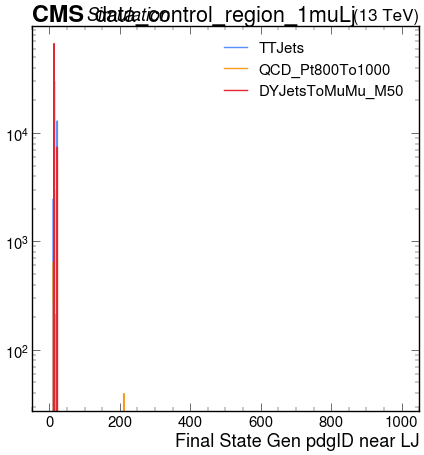

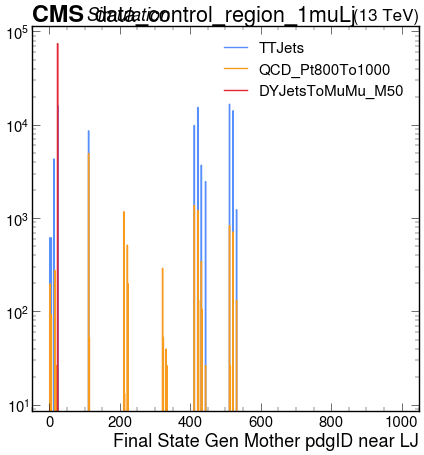

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


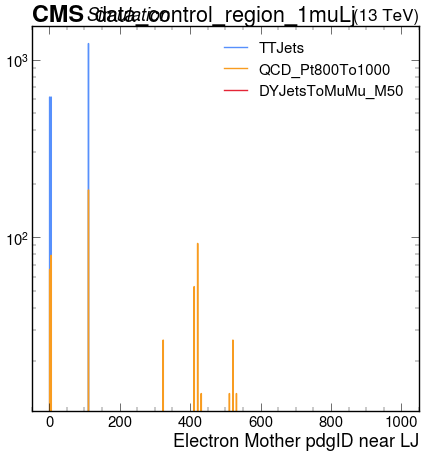

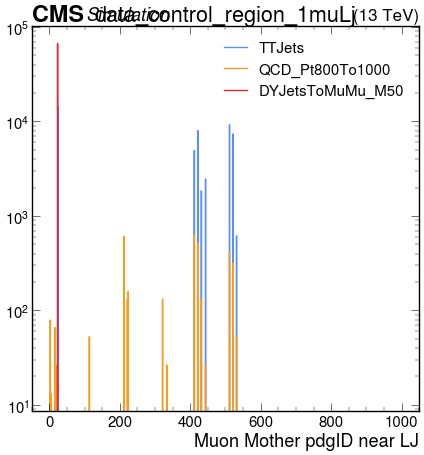

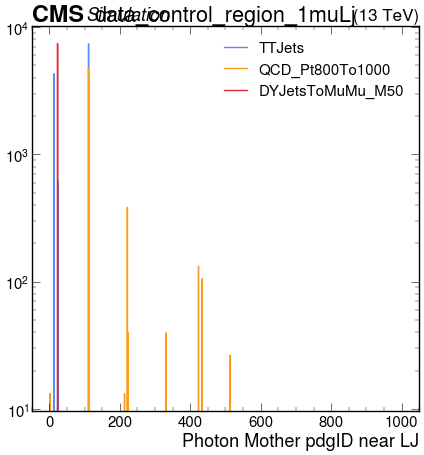

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


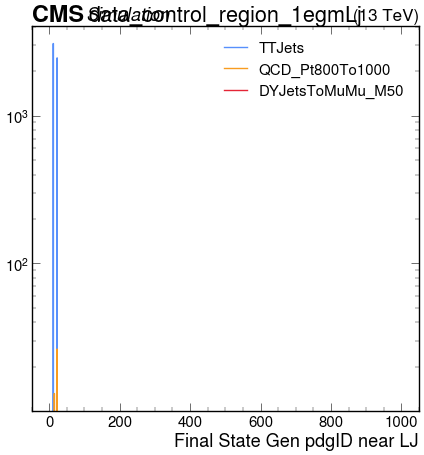

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


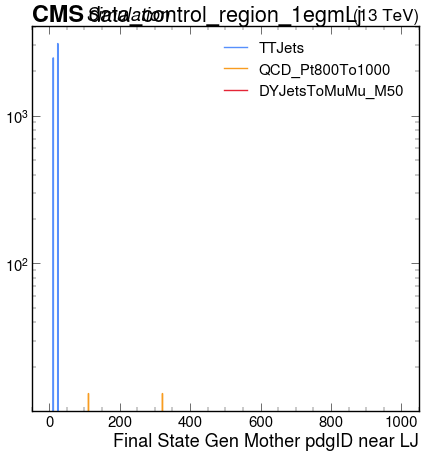

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


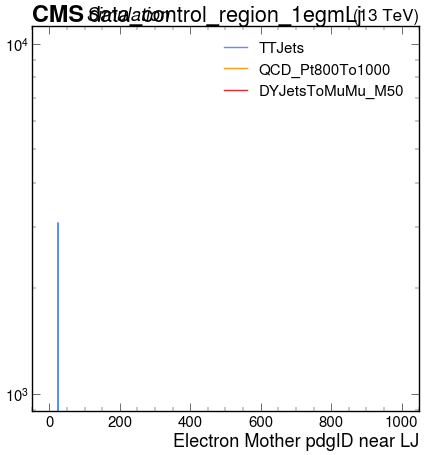

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3171/2756773512.py:16: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


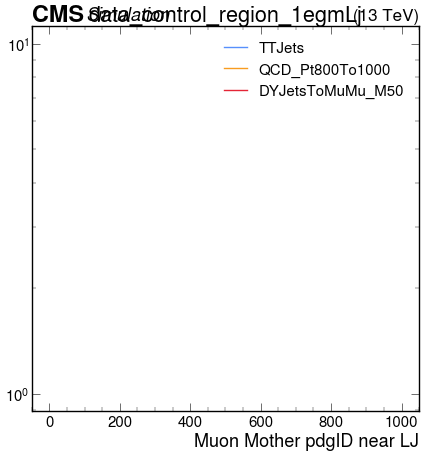

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


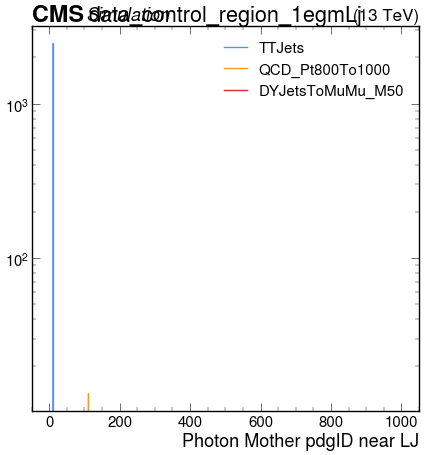

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


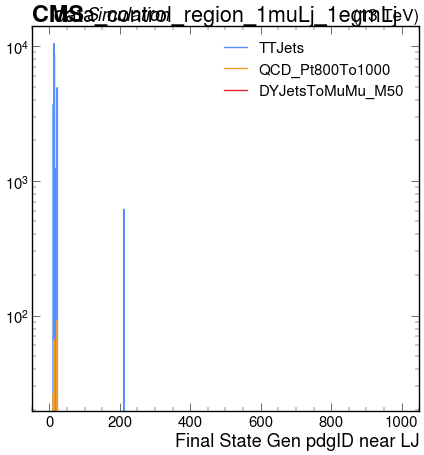

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


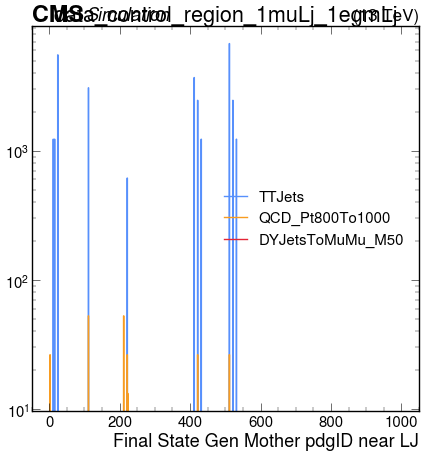

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


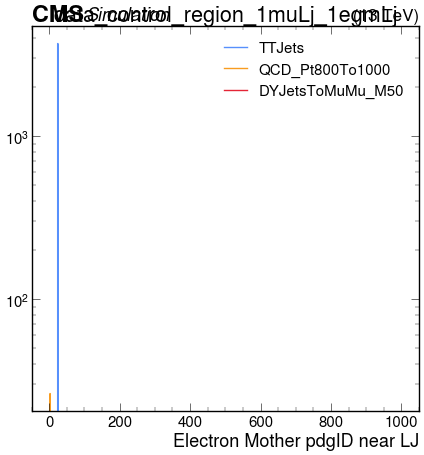

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


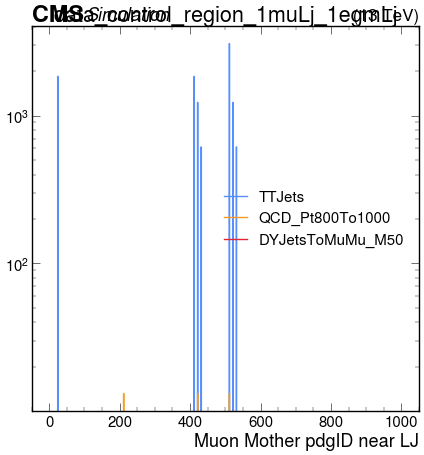

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


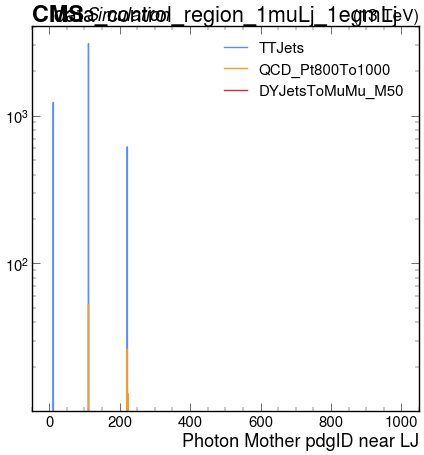

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


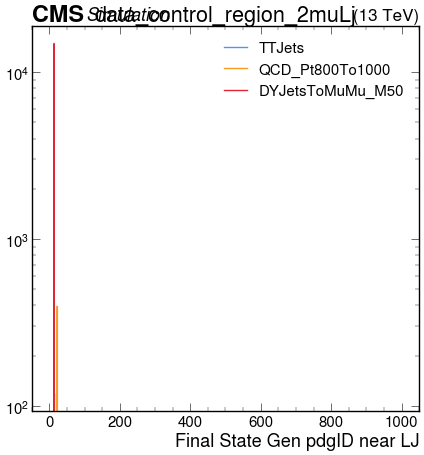

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


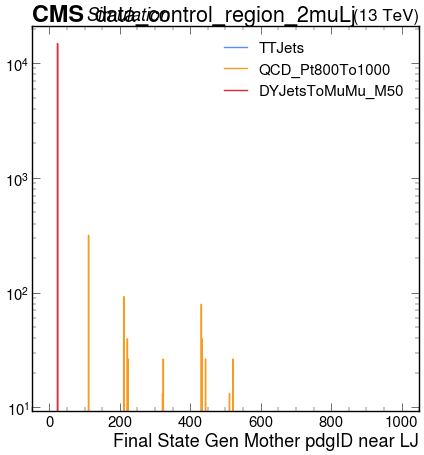

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3171/2756773512.py:16: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


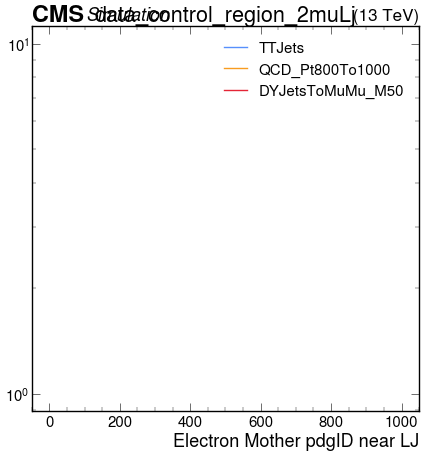

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


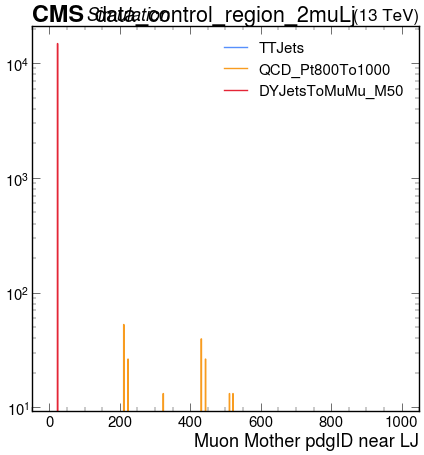

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


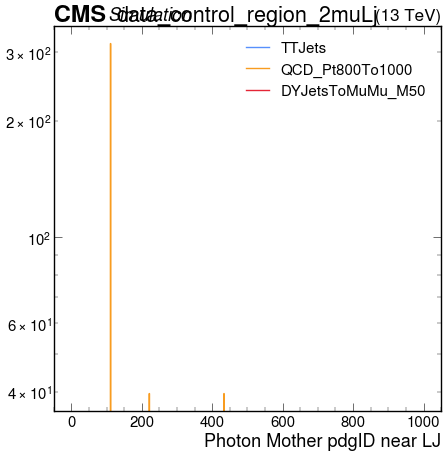

In [11]:
for channel in channels:
    for histogram_name in histogram_names:
        histograms = [
            output["out"][sample]["hists"][histogram_name][channel, :]
            for sample in samples
        ]
        utilities.plot(
            histograms,
            flow="none",
            yerr=False,
            density=False,
            linewidth=2,
            label=samples,
        )
        plt.title(channel)
        plt.yscale("log")
        plt.legend()
        plt.show()
        plt.close()

In [22]:
from collections import defaultdict
import pandas as pd
from IPython.display import display

SIGNAL_CATEGORY_ORDER = [
    "Dark Photon", "e", r"\mu", "Quark/Gluon", "Others",
]
BACKGROUND_CATEGORY_ORDER = [
    "Z", "W", "e", r"$\pi$", r"$\eta$/$\omega$",
    "B Meson", "D Meson", "Quark/Gluon", r"J/$Psi$", "Others",
]
OBJECT_HISTOGRAMS = {
    "Electron": "fs_e_gen_mother_id",
    "Muon": "fs_mu_gen_mother_id",
    "Photon": "fs_pho_gen_mother_id",
}

def categorize_signal_mother(pdgid):
    abs_id = abs(pdgid)
    if abs_id == 32:
        return "Dark Photon"
    if abs_id == 11:
        return "e"
    if abs_id == 13:
        return r"$\mu$"
    if abs_id in (1, 2, 3, 4, 5, 6, 9, 21):
        return "Quark/Gluon"
    return "Others"

def categorize_background_mother(pdgid):
    abs_id = abs(pdgid)
    if abs_id == 23:
        return "Z"
    if abs_id == 24:
        return "W"
    if abs_id == 11:
        return "e"
    if abs_id in (111, 211):
        return r"$\pi$"
    if abs_id in (221, 223):
        return r"$\eta$/$\omega$"
    if abs_id in (511, 521, 531, 541):
        return "B Meson"
    if abs_id in (411, 421, 423, 431):
        return "D Meson"
    if abs_id in (1, 2, 3, 4, 5, 6, 9, 21):
        return "Quark/Gluon"
    if abs_id == 443:
        return r"J/$\Psi$"
    return "Others"

def sum_hist_values(output, sample_names, channel, histogram_name):
    values = None
    for sample in sample_names:
        sample_values = output["out"][sample]["hists"][histogram_name][channel, :].values(flow=False)
        values = sample_values.copy() if values is None else values + sample_values
    return values

def categorize_hist_values(values, categorizer):
    category_counts = defaultdict(float)
    other_counts = defaultdict(float)
    for pdgid, count in enumerate(values):
        if count == 0:
            continue
        category = categorizer(pdgid)
        category_counts[category] += float(count)
        if category == "Others":
            other_counts[pdgid] += float(count)
    return category_counts, other_counts

def make_category_tables(output, sample_groups, channel, histogram_name, categorizer, category_order):
    yields = {}
    other_details = {}
    for group, sample_names in sample_groups.items():
        values = sum_hist_values(output, sample_names, channel, histogram_name)
        yields[group], other_details[group] = categorize_hist_values(values, categorizer)

    yield_table = pd.DataFrame(yields).T.fillna(0).reindex(columns=category_order, fill_value=0)
    totals = yield_table.sum(axis=1).replace(0, np.nan)
    fraction_table = yield_table.div(totals, axis=0).fillna(0)
    other_table = pd.DataFrame(other_details).T.fillna(0)
    if not other_table.empty:
        other_table = other_table.loc[:, (other_table != 0).any(axis=0)]
        other_table = other_table.reindex(sorted(other_table.columns), axis=1)
    return yield_table, fraction_table, other_table

def make_object_category_table(output, sample_names, channel, categorizer, category_order):
    object_counts = {}
    for object_name, histogram_name in OBJECT_HISTOGRAMS.items():
        values = sum_hist_values(output, sample_names, channel, histogram_name)
        object_counts[object_name], _ = categorize_hist_values(values, categorizer)
    return pd.DataFrame(object_counts).fillna(0).reindex(category_order, fill_value=0)

def plot_category_table(table, title, ylabel):
    ax = table.T.plot(kind="bar", figsize=(24, 12), width=0.8)
    ax.set_title(title)
    ax.set_xlabel("Mother category")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Process")
    plt.tight_layout()
    plt.show()
    plt.close()



data_control_region_1muLj: weighted object yield


,Z,W,e,$\pi$,$\eta$/$\omega$,B Meson,D Meson,Quark/Gluon,J/$Psi$,Others
DY,74227.710505,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
QCD,0.000000,0.000000,0,6101.991137,711.679312,1673.764307,3057.585192,461.273628,0,883.009517
TT,0.000000,15999.986304,0,8615.377240,0.000000,31999.972607,28923.052164,1230.768177,0,4307.688620


data_control_region_1muLj: category fraction


,Z,W,e,$\pi$,$\eta$/$\omega$,B Meson,D Meson,Quark/Gluon,J/$Psi$,Others
DY,1.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
QCD,0.0,0.000000,0.0,0.473415,0.055215,0.129857,0.237219,0.035787,0.0,0.068507
TT,0.0,0.175676,0.0,0.094595,0.000000,0.351351,0.317568,0.013514,0.0,0.047297


data_control_region_1muLj: Other mother PDG IDs


,13,15,113,213,321,323,331,333,433,513
DY,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
QCD,0.00000,276.764177,52.716986,13.179247,289.943423,52.716986,39.53774,26.358493,105.433972,26.358493
TT,4307.68862,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


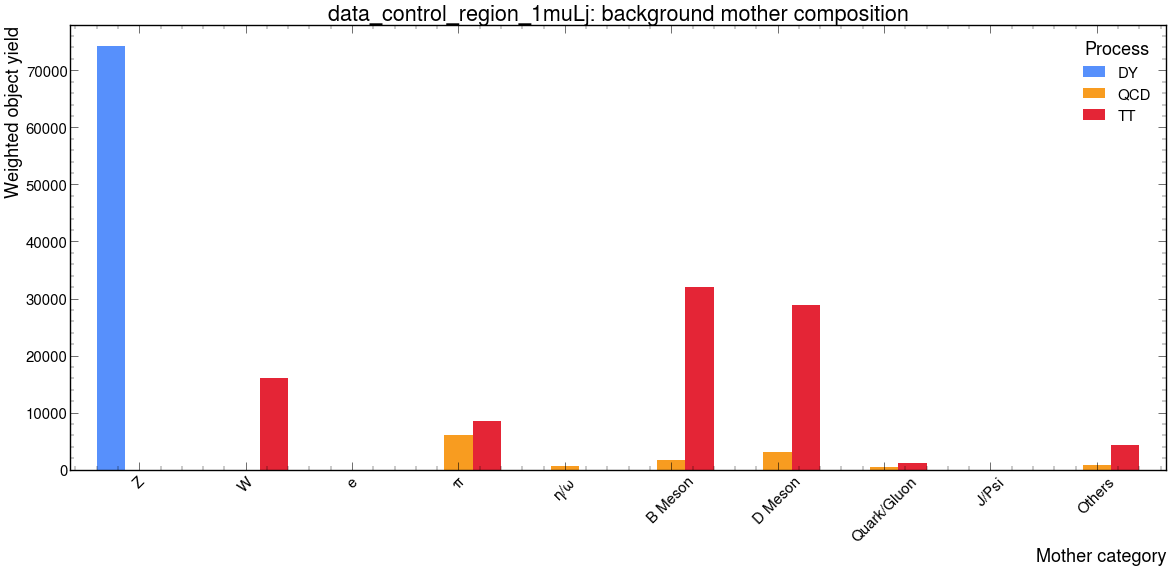

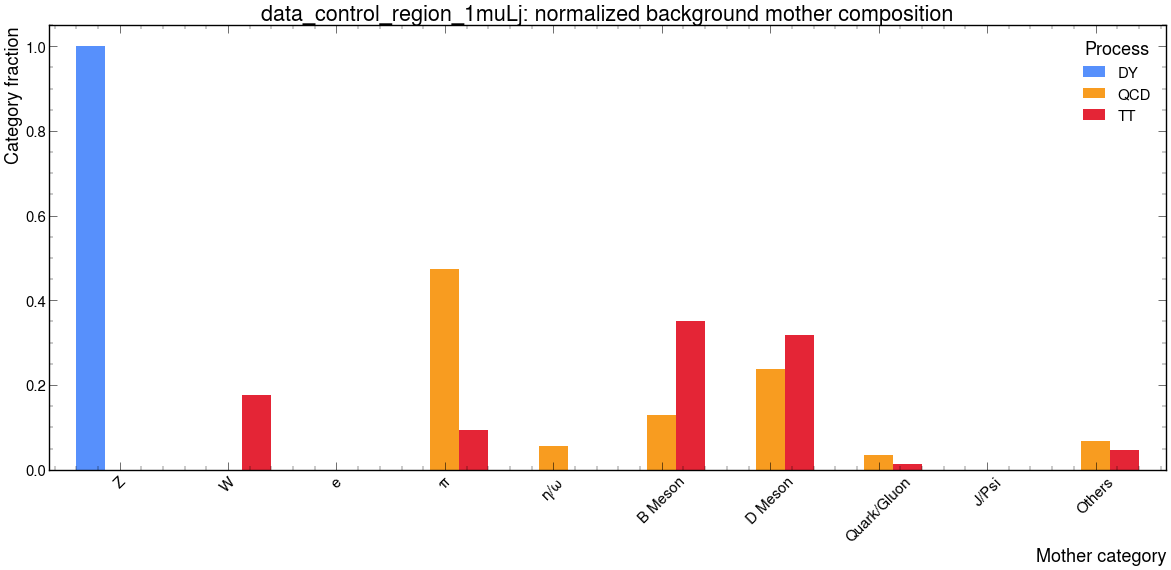


data_control_region_1egmLj: weighted object yield


,Z,W,e,$\pi$,$\eta$/$\omega$,B Meson,D Meson,Quark/Gluon,J/$Psi$,Others
DY,0,0.000000,0.000000,0.000000,0,0,0,0,0,0.000000
QCD,0,0.000000,0.000000,13.179247,0,0,0,0,0,13.179247
TT,0,3076.920443,2461.536354,0.000000,0,0,0,0,0,0.000000


data_control_region_1egmLj: category fraction


,Z,W,e,$\pi$,$\eta$/$\omega$,B Meson,D Meson,Quark/Gluon,J/$Psi$,Others
DY,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
QCD,0.0,0.000000,0.000000,0.5,0.0,0.0,0.0,0.0,0.0,0.5
TT,0.0,0.555556,0.444444,0.0,0.0,0.0,0.0,0.0,0.0,0.0


data_control_region_1egmLj: Other mother PDG IDs


,321
DY,0.000000
QCD,13.179247
TT,0.000000


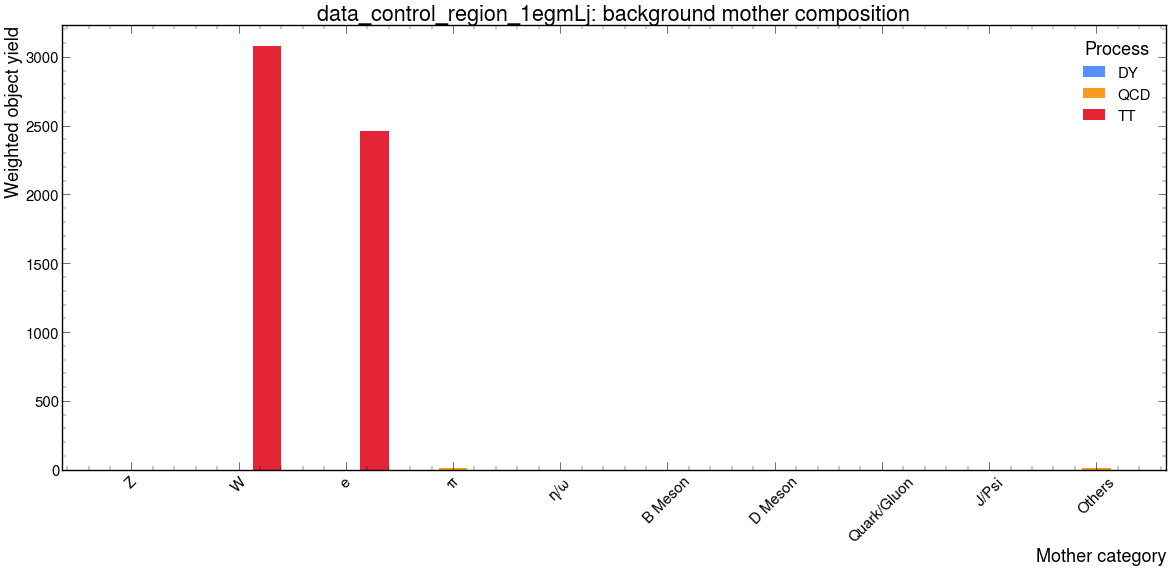

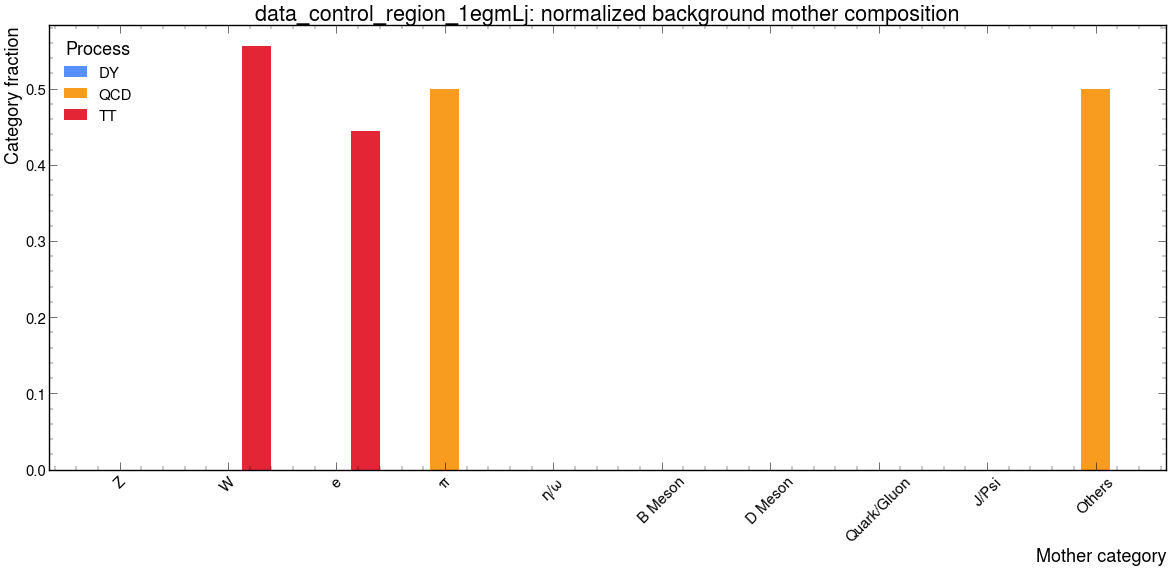


data_control_region_1muLj_1egmLj: weighted object yield


,Z,W,e,$\pi$,$\eta$/$\omega$,B Meson,D Meson,Quark/Gluon,J/$Psi$,Others
DY,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
QCD,0,0.000000,0.000000,105.433972,39.537740,26.358493,26.358493,26.358493,0,0.000000
TT,0,5538.456797,1230.768177,3076.920443,615.384089,10461.529506,7384.609063,0.000000,0,1230.768177


data_control_region_1muLj_1egmLj: category fraction


,Z,W,e,$\pi$,$\eta$/$\omega$,B Meson,D Meson,Quark/Gluon,J/$Psi$,Others
DY,0.0,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
QCD,0.0,0.0000,0.000000,0.470588,0.176471,0.117647,0.117647,0.117647,0.0,0.000000
TT,0.0,0.1875,0.041667,0.104167,0.020833,0.354167,0.250000,0.000000,0.0,0.041667


data_control_region_1muLj_1egmLj: Other mother PDG IDs


,15
DY,0.000000
QCD,0.000000
TT,1230.768177


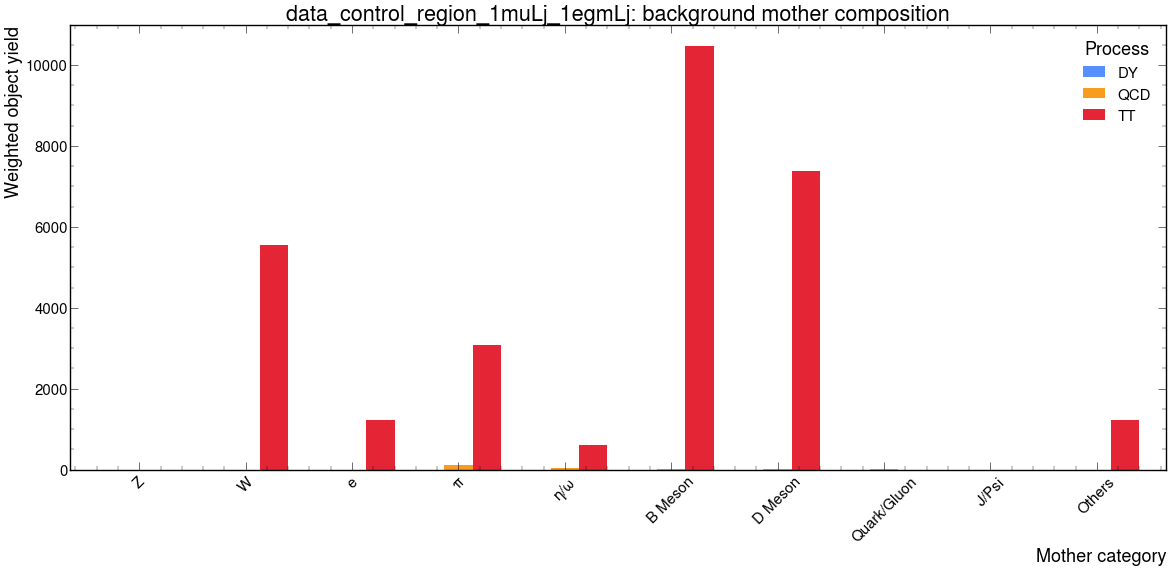

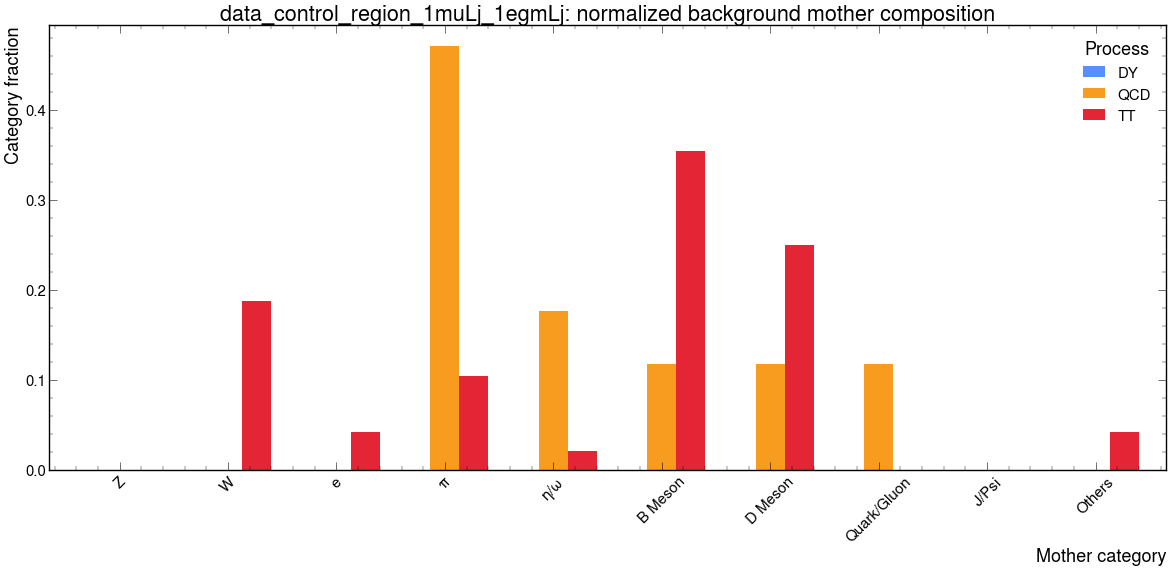


data_control_region_2muLj: weighted object yield


,Z,W,e,$\pi$,$\eta$/$\omega$,B Meson,D Meson,Quark/Gluon,J/$Psi$,Others
DY,14845.542101,0,0,0.000000,0.000000,0.00000,0.000000,0,0,0.000000
QCD,0.000000,0,0,408.556642,65.896233,39.53774,79.075479,0,0,79.075479
TT,0.000000,0,0,0.000000,0.000000,0.00000,0.000000,0,0,0.000000


data_control_region_2muLj: category fraction


,Z,W,e,$\pi$,$\eta$/$\omega$,B Meson,D Meson,Quark/Gluon,J/$Psi$,Others
DY,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
QCD,0.0,0.0,0.0,0.607843,0.098039,0.058824,0.117647,0.0,0.0,0.117647
TT,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000


data_control_region_2muLj: Other mother PDG IDs


,321,323,433
DY,0.000000,0.000000,0.00000
QCD,13.179247,26.358493,39.53774
TT,0.000000,0.000000,0.00000


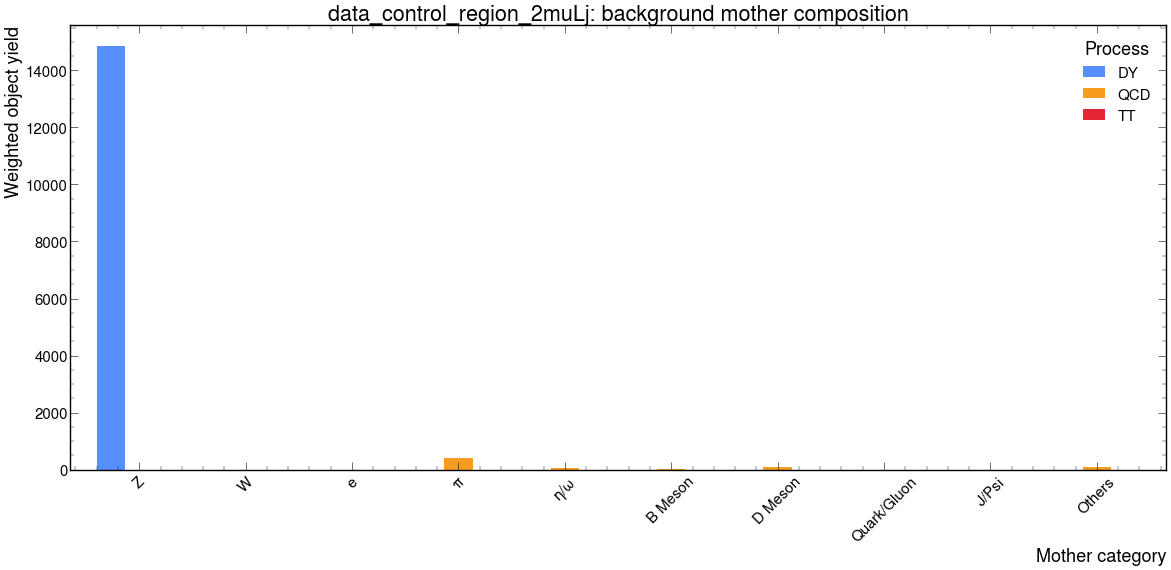

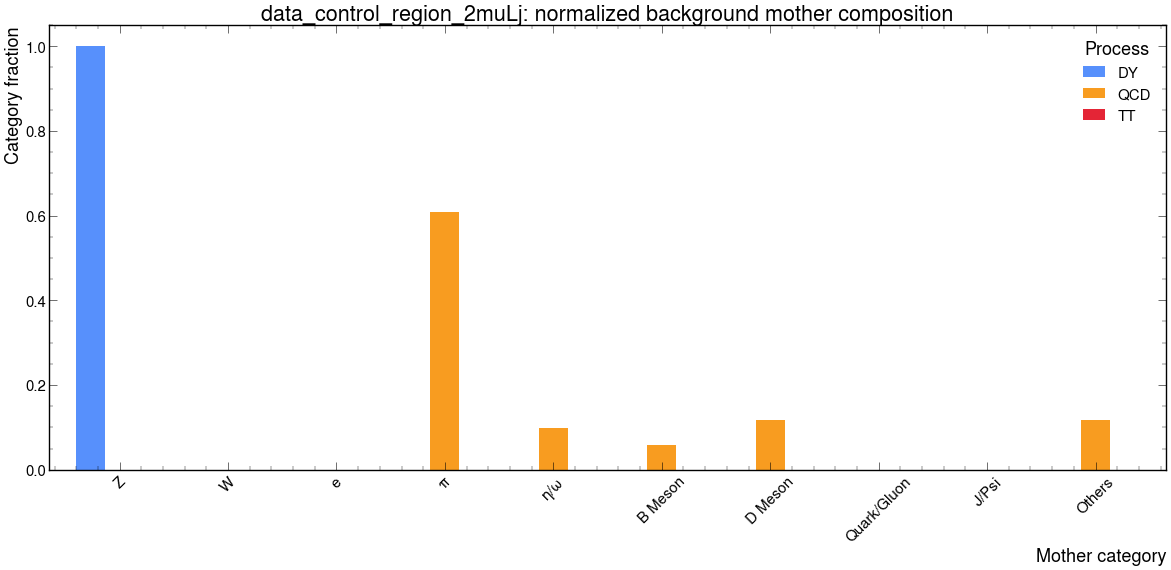

In [23]:
background_groups = {
    "DY": ["DYJetsToMuMu_M50"],
    "QCD": ["QCD_Pt800To1000"],
    "TT": ["TTJets"],
}

background_tables = {}
for channel in channels:
    yield_table, fraction_table, other_table = make_category_tables(
        output,
        background_groups,
        channel,
        "fs_gen_mother_id",
        categorize_background_mother,
        BACKGROUND_CATEGORY_ORDER,
    )
    background_tables[channel] = {
        "yield": yield_table,
        "fraction": fraction_table,
        "other": other_table,
    }

    print()
    print(f"{channel}: weighted object yield")
    display(yield_table)
    print(f"{channel}: category fraction")
    display(fraction_table)
    print(f"{channel}: Other mother PDG IDs")
    display(other_table)

    plot_category_table(
        yield_table,
        f"{channel}: background mother composition",
        "Weighted object yield",
    )
    plot_category_table(
        fraction_table,
        f"{channel}: normalized background mother composition",
        "Category fraction",
    )


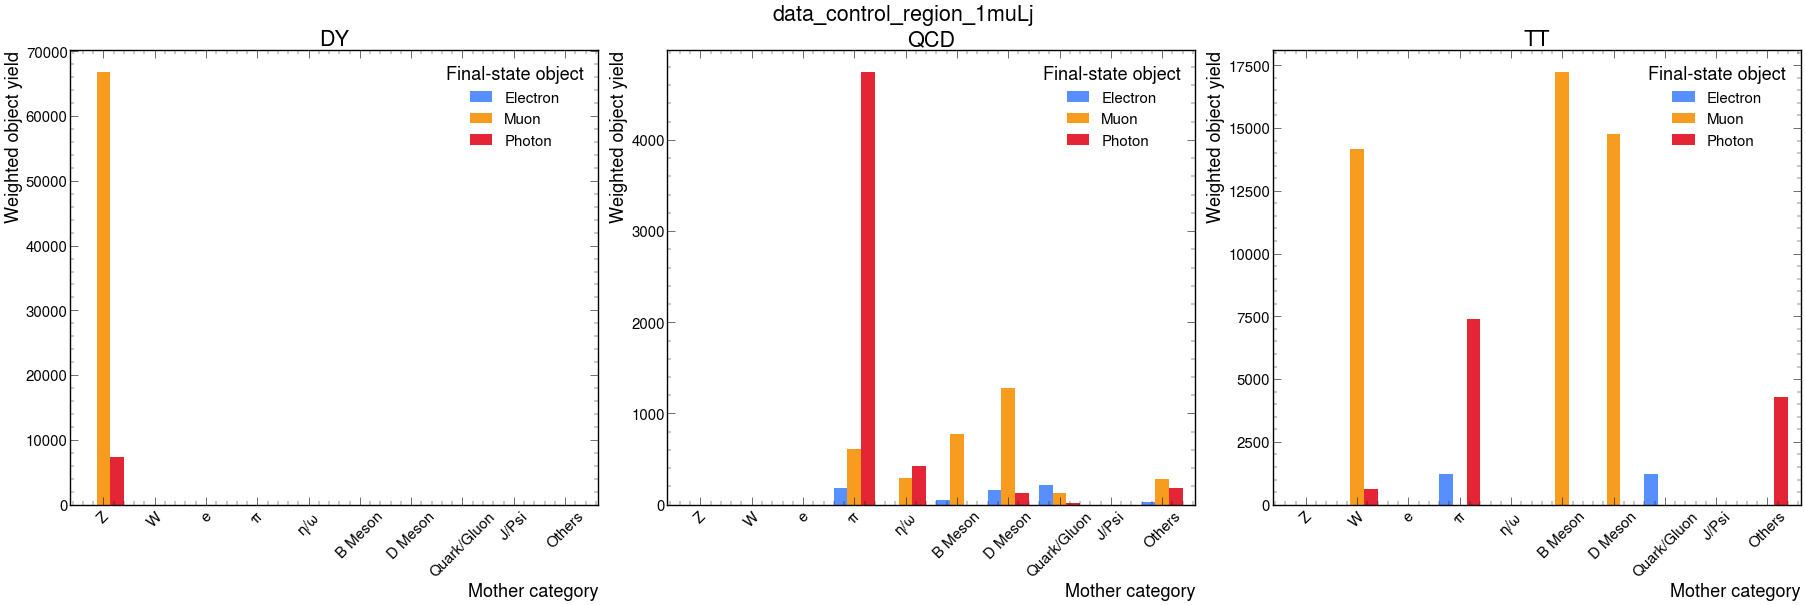

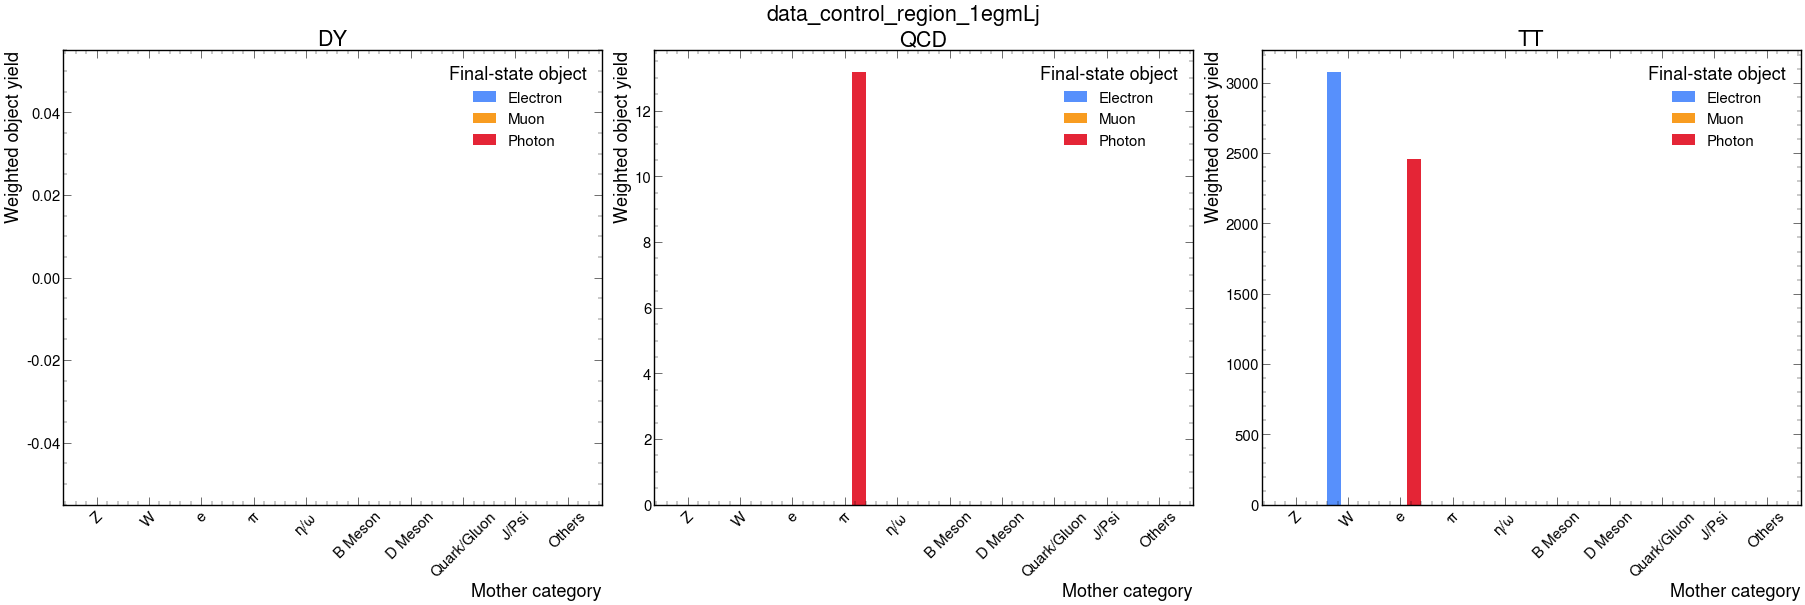

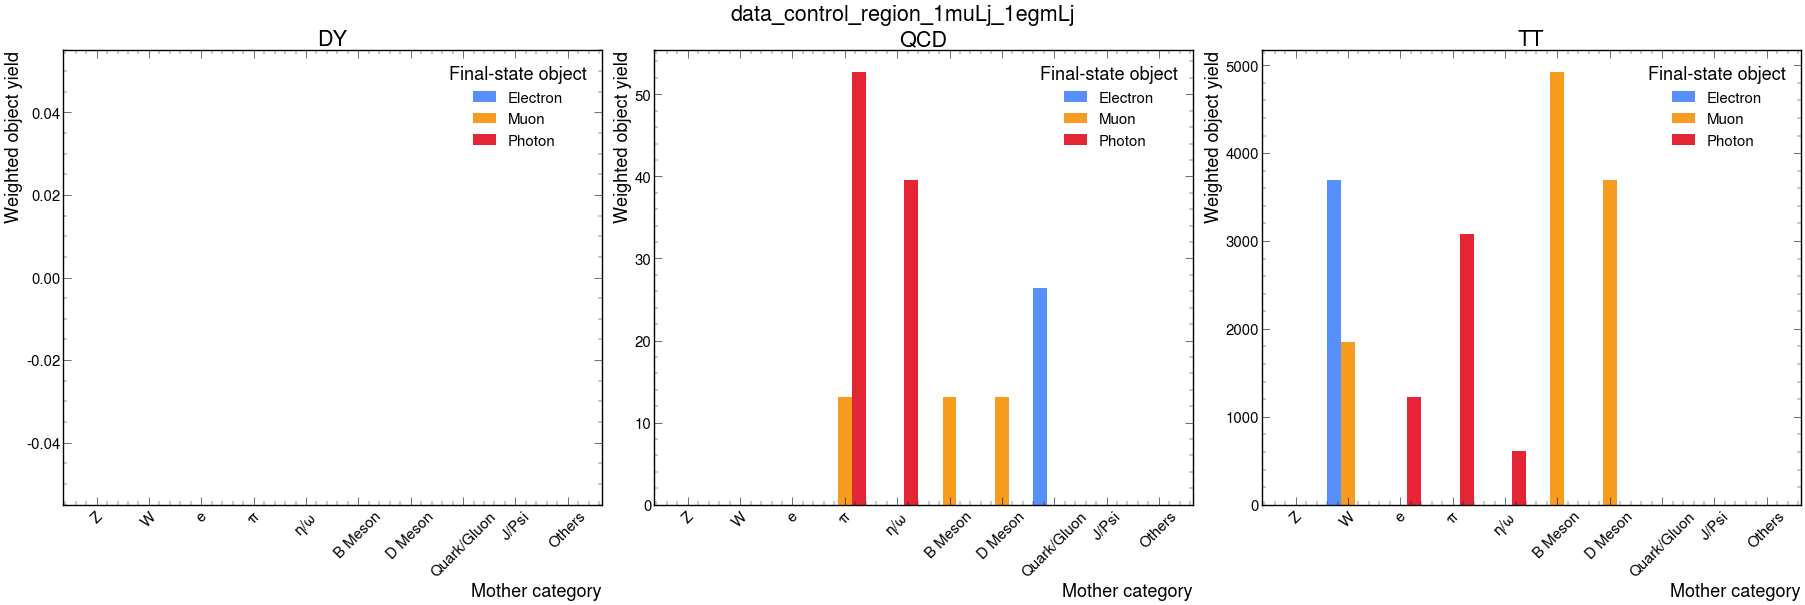

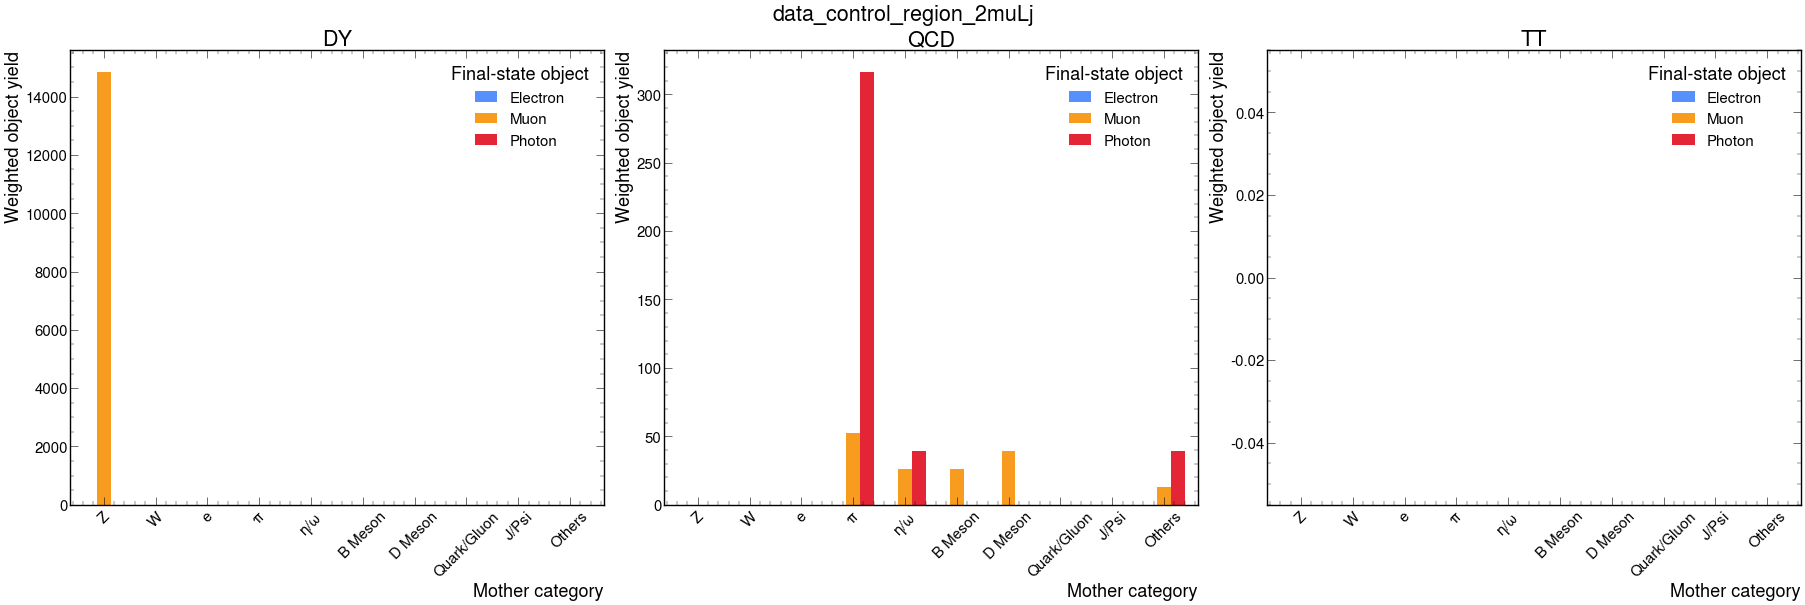

In [26]:
for channel in channels:
    fig, axes = plt.subplots(1, len(background_groups), figsize=(36, 12), constrained_layout=True)
    for ax, (group, sample_names) in zip(axes, background_groups.items()):
        object_table = make_object_category_table(
            output,
            sample_names,
            channel,
            categorize_background_mother,
            BACKGROUND_CATEGORY_ORDER,
        )
        object_table.plot(kind="bar", ax=ax, width=0.8)
        ax.set_title(group)
        ax.set_xlabel("Mother category")
        ax.set_ylabel("Weighted object yield")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title="Final-state object")
    fig.suptitle(channel)
    plt.show()
    plt.close()


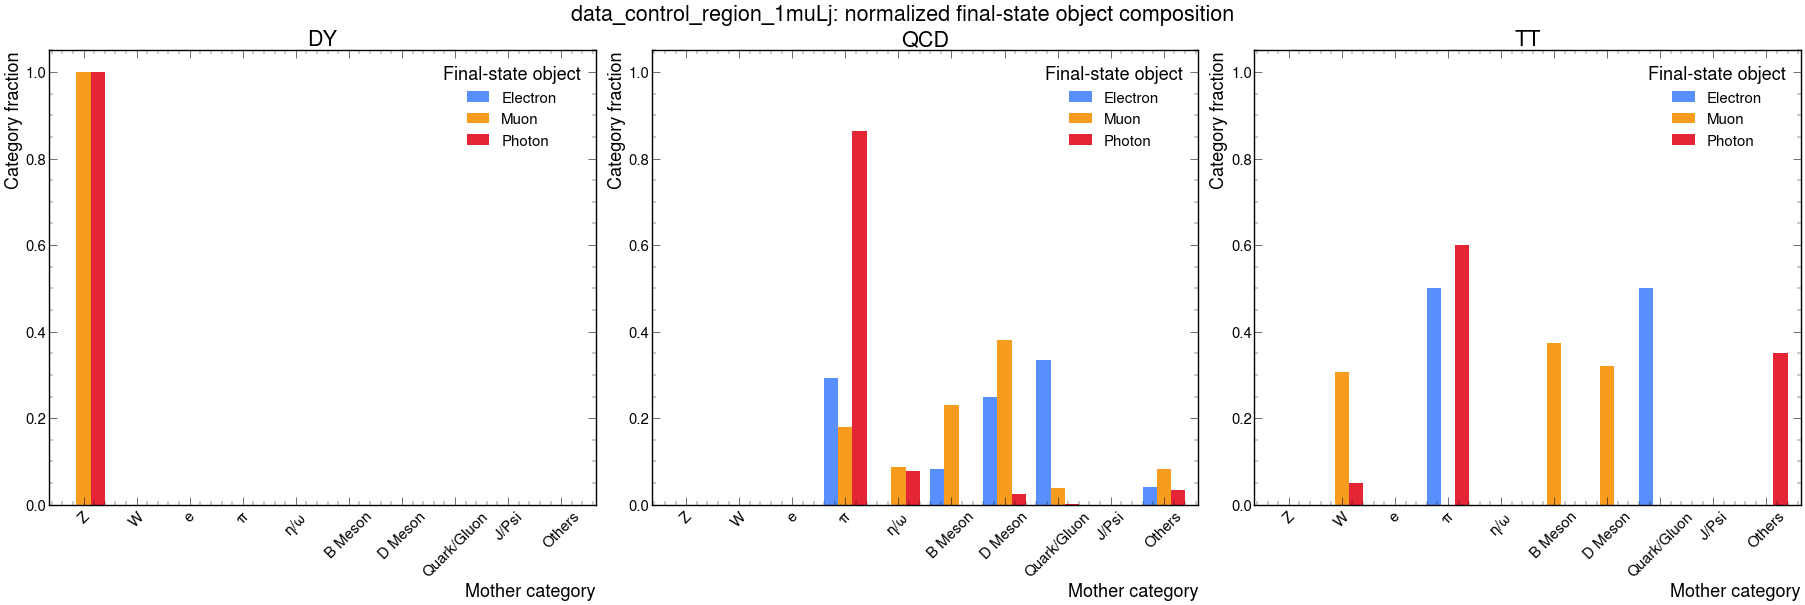

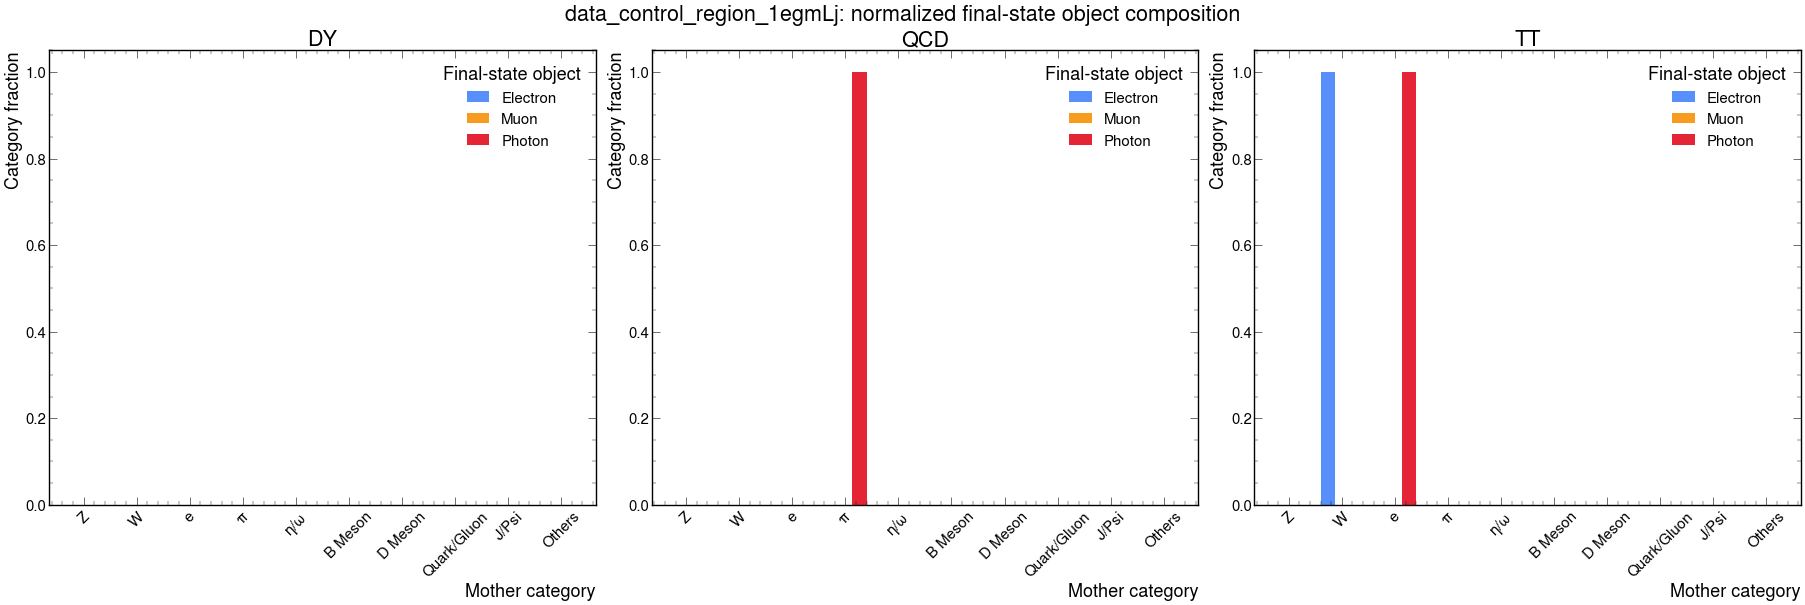

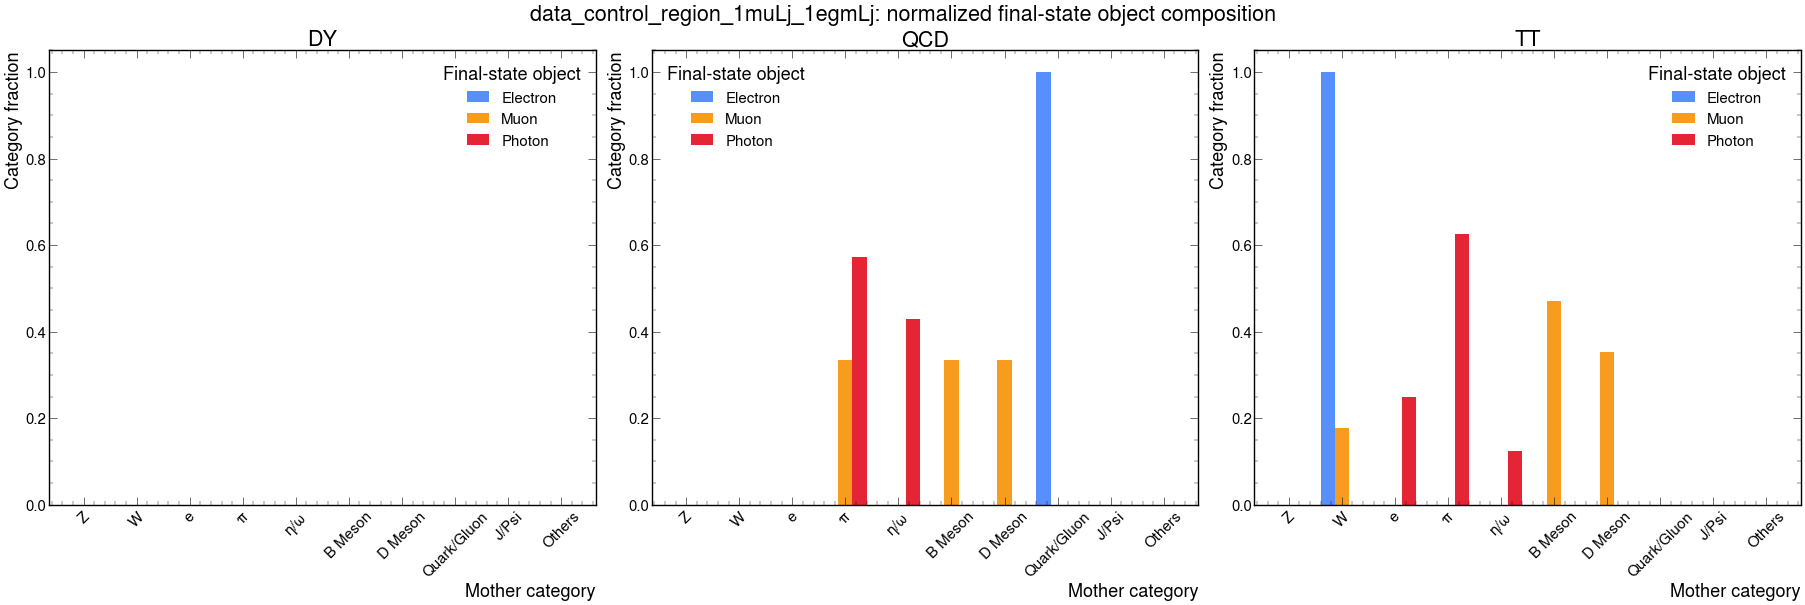

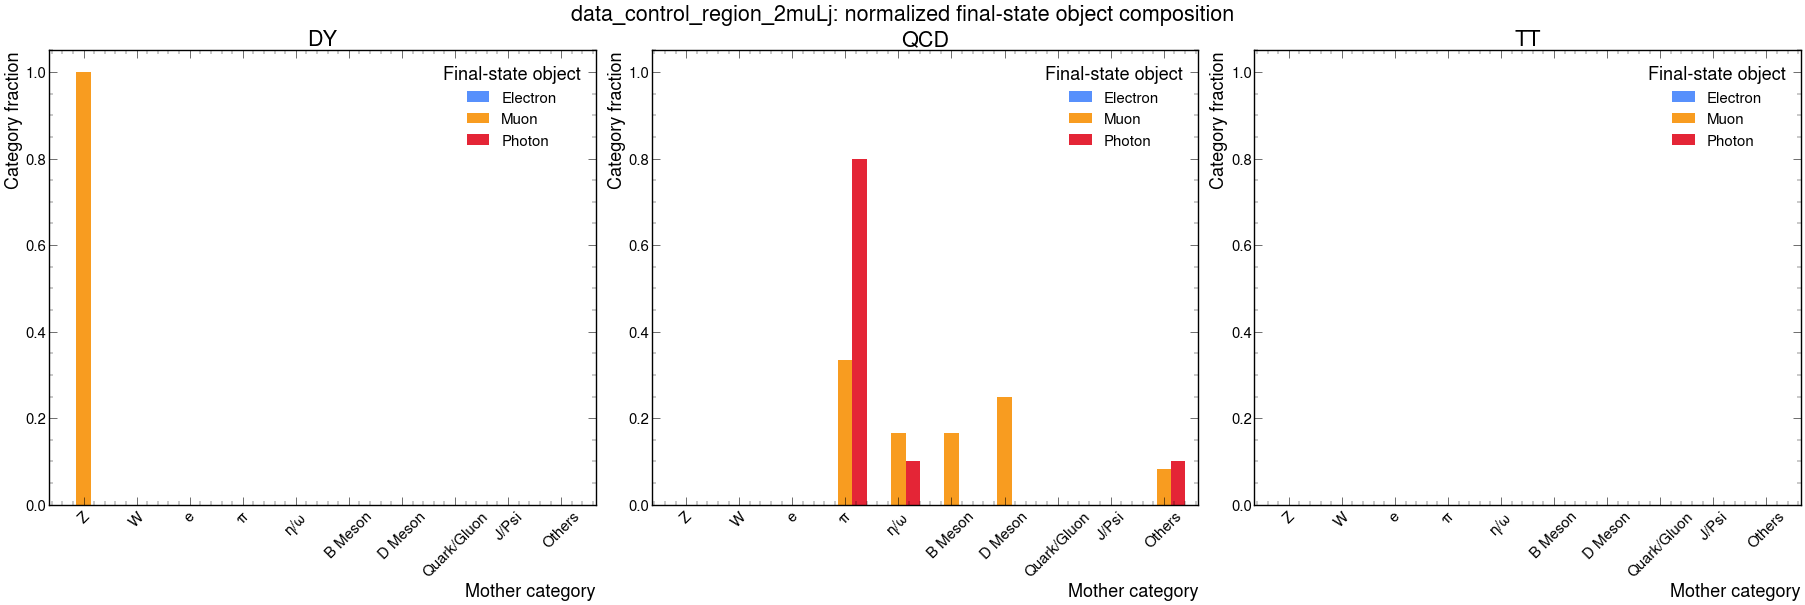

In [29]:
for channel in channels:
    fig, axes = plt.subplots(1, len(background_groups), figsize=(36, 12), constrained_layout=True)
    for ax, (group, sample_names) in zip(axes, background_groups.items()):
        object_table = make_object_category_table(
            output,
            sample_names,
            channel,
            categorize_background_mother,
            BACKGROUND_CATEGORY_ORDER,
        )
        object_totals = object_table.sum(axis=0).replace(0, np.nan)
        object_fraction_table = object_table.div(object_totals, axis=1).fillna(0)

        object_fraction_table.plot(kind="bar", ax=ax, width=0.8)
        ax.set_title(group)
        ax.set_xlabel("Mother category")
        ax.set_ylabel("Category fraction")
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title="Final-state object")
    fig.suptitle(f"{channel}: normalized final-state object composition")
    plt.show()
    plt.close()
